#  **Análise de Dados Ifood**

Este projeto analisa dados de todos os restaurantes disponíveis na plataforma iFood
em dois períodos distintos (novembro de 2020 e fevereiro de 2021), com o objetivo de
entender a estrutura do marketplace, o perfil dos restaurantes e as mudanças ocorridas
ao longo do tempo.A análise foi realizada em Python utilizando pandas e matplotlib, passando por etapas
de limpeza de dados, análise exploratória (EDA) e comparação temporal entre os períodos.
Foram avaliados aspectos como categorias de restaurantes, faixa de preço, taxas de
entrega e distribuição geográfica. Os resultados indicam forte concentração do marketplace em poucas categorias, como
fast food, além de crescimento no número de restaurantes no período analisado, possivelmente
influenciado pela pandemia e pela digitalização do setor de alimentação.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_2020 = pd.read_csv(
    r"C:\Users\pedro\Downloads\archive\ifood-restaurants-november-2020.csv"
)

df_2021 = pd.read_csv(
    r"C:\Users\pedro\Downloads\archive\ifood-restaurants-february-2021.csv"
)

In [4]:
df_2020["year"] = 2020
df_2021["year"] = 2021

In [5]:
df_2020["year"].head()

0    2020
1    2020
2    2020
3    2020
4    2020
Name: year, dtype: int64

In [6]:
df_2021["year"].head()

0    2021
1    2021
2    2021
3    2021
4    2021
Name: year, dtype: int64

In [7]:
common_columns = set(df_2020.columns).intersection(set(df_2021.columns))

df_2020 = df_2020[list(common_columns)]
df_2021 = df_2021[list(common_columns)]

In [9]:
df = pd.concat([df_2020, df_2021], ignore_index=True)

In [10]:
df.shape

(767846, 10)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767846 entries, 0 to 767845
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   avatar         767271 non-null  object 
 1   price_range    767846 non-null  object 
 2   url            767846 non-null  object 
 3   year           767846 non-null  int64  
 4   category       767846 non-null  object 
 5   delivery_time  767846 non-null  int64  
 6   name           767846 non-null  object 
 7   rating         767846 non-null  float64
 8   delivery_fee   767846 non-null  float64
 9   distance       767846 non-null  float64
dtypes: float64(3), int64(2), object(5)
memory usage: 58.6+ MB


In [12]:
df.head()

,avatar,price_range,url,year,category,delivery_time,name,rating,delivery_fee,distance
0,https://static-images.ifood.com.br/image/uploa...,CHEAP,https://www.ifood.com.br/delivery/vitoria-de-s...,2020,Lanches,80,El'moedor,4.30303,9.00,6.20
1,https://static-images.ifood.com.br/image/uploa...,CHEAPEST,https://www.ifood.com.br/delivery/moreno-pe/de...,2020,Doces & Bolos,35,Delicia de Brigadeiro,0.00000,6.00,3.03
2,https://static-images.ifood.com.br/image/uploa...,CHEAPEST,https://www.ifood.com.br/delivery/moreno-pe/pi...,2020,Brasileira,40,Pizzaria Rappi10 - Moreno,0.00000,4.00,1.51
3,https://static-images.ifood.com.br/image/uploa...,CHEAPEST,https://www.ifood.com.br/delivery/jaboatao-dos...,2020,Lanches,50,Tapioca Arretada,5.00000,0.00,0.79
4,https://static-images.ifood.com.br/image/uploa...,CHEAPEST,https://www.ifood.com.br/delivery/jaboatao-dos...,2020,Salgados,36,Minuto Kit Festa ( Salgados e Doces ),5.00000,12.99,5.12


In [13]:
df = df.drop_duplicates()

In [14]:
if "delivery_fee" in df.columns:
    df["delivery_fee"] = pd.to_numeric(df["delivery_fee"], errors="coerce")

In [15]:
if "distance" in df.columns:
    df["distance"] = pd.to_numeric(df["distance"], errors="coerce")

# **Análise Exploratória dos dados**

**Categorias mais comuns**

In [17]:
df["category"].value_counts().head(10)

category
Lanches          188277
Brasileira       140375
Doces & Bolos     73869
Pizza             70616
Açaí              39947
Marmita           31056
Japonesa          26900
Bebidas           24481
Saudável          19230
Salgados          18258
Name: count, dtype: int64

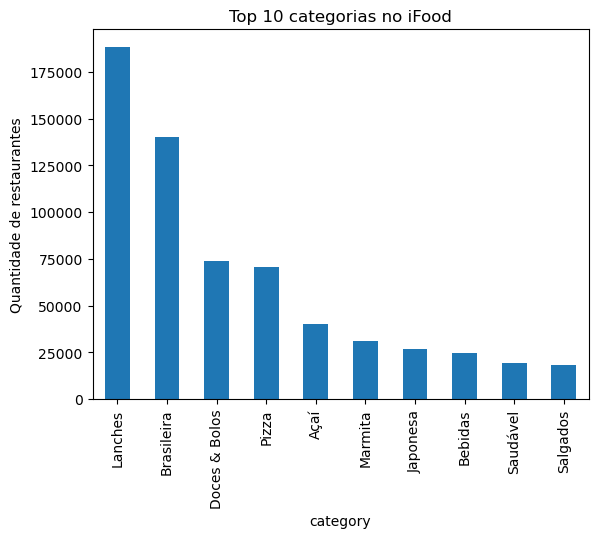

In [18]:
df["category"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 categorias no iFood")
plt.ylabel("Quantidade de restaurantes")
plt.show()

In [22]:
category_counts = df["category"].value_counts(normalize=True) * 100
category_counts

category
Lanches            24.520151
Brasileira         18.281661
Doces & Bolos       9.620288
Pizza               9.196636
Açaí                5.202475
                     ...    
Típica do Norte     0.007554
Grega               0.001172
Paranaense          0.001042
Churrasco Grego     0.000130
Marroquina          0.000130
Name: proportion, Length: 62, dtype: float64

Conseguimos identificar que dentro da plataforma a categoria de Lanches possui uma predominança dentre as categorias, com 24% dos pedidos na plataforma. Ao mesmo tempo identificamos que comida marroquina, não possui uma procura tão grande dentre os pedidos.

**Faixa de Preço**

In [23]:
df["price_range"].value_counts(normalize=True) * 100

price_range
CHEAPEST          70.711835
MODERATE          11.688021
CHEAP             11.249782
EXPENSIVE          4.115148
MOST_EXPENSIVE     2.235214
Name: proportion, dtype: float64

Podemos ver que a faixa de preço se concentra em restaurantes com faixas mais acessíveis.

**Taxa de Entrega**

In [26]:
df['delivery_fee'].describe()

count    767846.000000
mean          6.637840
std           4.202388
min           0.000000
25%           4.000000
50%           5.990000
75%           9.000000
max          40.000000
Name: delivery_fee, dtype: float64

In [27]:
df[df["delivery_fee"] == 0].shape[0]

99271

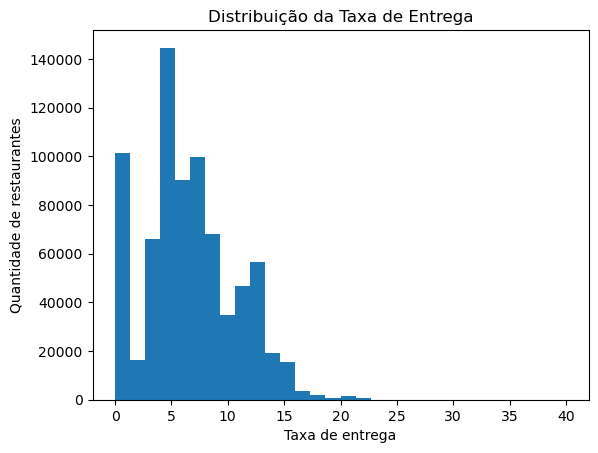

In [28]:
plt.figure()
df["delivery_fee"].dropna().plot(kind="hist", bins=30)
plt.title("Distribuição da Taxa de Entrega")
plt.xlabel("Taxa de entrega")
plt.ylabel("Quantidade de restaurantes")
plt.show()

A respeito das taxas de entrega identificamos que o preço médio de taxa de entrega é de R$6,64 nesse período e que 13% dos pedidos nesse período tiveram taxa zero.

**Comparação entre 2020 e 2021**

Quantidade de restaurantes no período

In [32]:
df.groupby("year").size()

year
2020    361447
2021    406399
dtype: int64

In [ ]:
No período tivemos um aumento de 

Comparação de categorias

In [33]:
cat_year = (
    df.groupby(["year", "category"])
      .size()
      .reset_index(name="count")
)

In [34]:
pivot_cat = cat_year.pivot(
    index="category",
    columns="year",
    values="count"
).fillna(0)

In [35]:
pivot_cat["diff"] = pivot_cat[2021] - pivot_cat[2020]
pivot_cat.sort_values("diff", ascending=False).head(10)

year,2020,2021,diff
category,,,
Lanches,89331.0,98946.0,9615.0
Brasileira,67027.0,73348.0,6321.0
Doces & Bolos,34041.0,39828.0,5787.0
Açaí,17837.0,22110.0,4273.0
Pizza,33797.0,36819.0,3022.0
Bebidas,11106.0,13375.0,2269.0
Marmita,14489.0,16567.0,2078.0
Japonesa,12757.0,14143.0,1386.0
Mercado,2293.0,3625.0,1332.0


Taxa média por ano

In [42]:
df.groupby("year")["delivery_fee"].mean()

year
2020    6.450367
2021    6.804577
Name: delivery_fee, dtype: float64

Os resultados indicam forte concentração do marketplace em poucas categorias, como
fast food, além de crescimento no número de restaurantes no período analisado, possivelmente
influenciado pela pandemia e pela digitalização do setor de alimentação.